In [894]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from collections import Counter
import random 

# Theme of the Project

This project investigates the mathematical foundations of cryptography
through the implementation and analysis of classical and modern
encryption schemes. Spread across multiple notebooks, it uses Python,
NumPy, and SymPy to explore modular arithmetic and linear algebra as
the theoretical basis for the Caesar cipher, Vigenère cipher, and the
matrix-based Hill cipher — including a full cryptanalytic attack on
each. The project then transitions to modern cryptography, implementing
RSA encryption and digital signatures from scratch, alongside
demonstrations of AES symmetric encryption, cryptographic hash
functions, and secure randomness. Throughout, the focus is on bridging
the gap between abstract mathematical concepts and their practical
application in secure communication, with each notebook building
directly on the mathematical tools established before it.

## Table of Contents

1. Mathematical Foundations
   - 1.1 Modular Arithmetic
   - 1.2 GCD & The Euclidean Algorithm
   - 1.3 Modular Inverse
   - 1.4 Matrix Operations in Cryptography
2. Classical Ciphers
   - 2.1 Caesar Cipher
   - 2.2 Vigenère Cipher
   - 2.3 Frequency Analysis
3. Hill Cipher
   - 3.1 Encryption
   - 3.2 Decryption
   - 3.3 Known-Plaintext Attack

4. Modern Cryptography
   - 4.1 RSA
      - 4.1.1 Euler's Theorem
      - 4.1.2 Miller-Rabin Primality Test
      - 4.1.3 Prime Generation
      - 4.1.4 Encryption & Decryption
   - 4.2 Digital Signatures
   - 4.3 Hashing
   - 4.4 AES — Symmetric Encryption
   - 4.5 Cryptographically Secure Randomness
   - 4.6 The Quantum Computing Threat

5. Conclusion

## 1. Mathematical Foundations

Before implementing any cipher, we establish the three mathematical 
tools that all cryptographic schemes in this project rely on:

- **Modular arithmetic** — the algebra of remainders, forming the 
  basis of all letter transformations
- **Greatest Common Divisor (GCD)** — used to determine whether a 
  number or matrix is invertible in modular space
- **Matrix operations (mod n)** — the foundation of block ciphers 
  such as the Hill cipher, where encryption is a linear transformation
  over a finite field

### 1.1 Modular Arithmetic

Modular arithmetic is a mathematical system where integers "wrap around" 
after exceeding a given value called the **modulus**. Formally:

$$a \equiv b \pmod{m} \iff m \mid (a - b)$$

We say $a$ is congruent to $b$ modulo $m$ if $m$ divides their difference.

For example:

$$3 \equiv 15 \pmod{12} \quad \text{since } 12 \mid (15 - 3)$$
$$70 \equiv 10 \pmod{60} \quad \text{since } 60 \mid (70 - 10)$$

In cryptography, modular arithmetic keeps all values within a fixed range.
For classical ciphers this range is $\mathbb{Z}_{26} = \{0, 1, \dots, 25\}$,
where each integer represents a letter of the English alphabet:

$$27 \equiv 1 \pmod{26}$$
$$34 \equiv 8 \pmod{26}$$

The following cell shows the implementation in python:

In [895]:
print(27 % 26)  # 1
print(34 % 26)  # 8
print(-6 % 26)

1
8
20



### 1.2 Greatest Common Divisor (GCD)

The Greatest Common Divisor of two integers is the largest integer 
that divides both without a remainder:

$$\gcd(a, b) = \max\{d \in \mathbb{Z}^+ : d \mid a \text{ and } d \mid b\}$$

Two integers are called **coprime** if their GCD equals 1:

$$\gcd(a, b) = 1$$

This is not an edge case — it is the fundamental requirement in 
cryptography. A number $a$ has a modular inverse mod $m$ **if and 
only if** $\gcd(a, m) = 1$.

### The Euclidean Algorithm

Rather than factoring both numbers, we use the recursive observation:

$$\gcd(a, b) = \gcd(b,\ a \bmod b)$$

repeated until the remainder reaches zero. For example:

$$\gcd(48, 18) \rightarrow \gcd(18, 12) \rightarrow \gcd(12, 6) 
\rightarrow \gcd(6, 0) = 6$$

In the context of this project, the condition we require is:

$$\gcd(a, 26) = 1$$

For example $\gcd(3, 26) = 1$ so $3$ is a valid key, 
while $\gcd(13, 26) = 13$ so $13$ is not.

The following cell shows the implementation in python:

In [896]:
def findGCD(a,b):
    if b == 0:
        return a
    return findGCD(b,a % b)    

In [897]:
print(findGCD(3,26))
print(findGCD(18,48))
print(findGCD(2,4))


1
6
2


SymPy provides a built-in gcd function which we use to verify our implementation:

In [898]:
assert sp.gcd(3,26) == findGCD(3,26)
assert sp.gcd(18,48) == findGCD(18,48)
assert sp.gcd(2,4) == findGCD(2,4)
assert sp.gcd(47,123) == findGCD(47,123) 


### 1.3 Modular Inverse

The modular inverse of $a$ modulo $m$ is an integer $x$ such that:

$$a \cdot x \equiv 1 \pmod{m}$$

For example, the modular inverse of $3$ mod $26$ is $9$, since:

$$3 \times 9 = 27 \equiv 1 \pmod{26}$$

A modular inverse exists **if and only if**:

$$\gcd(a, m) = 1$$

We find it using the **Extended Euclidean Algorithm**, which finds 
integers $x$ and $y$ satisfying Bézout's identity:

$$ax + my = \gcd(a, m)$$

When $\gcd(a, m) = 1$, the coefficient $x$ reduced mod $m$ is 
the modular inverse of $a$.

The following cell shows the implementation in python: 

In [899]:
def extended_euclidian(a,modular):
    curr_number = a
    next_number = modular
    current_coefficient = 1
    next_coefficient = 0
    while next_number != 0 : 
        q = curr_number // next_number
        curr_number , next_number = next_number, curr_number - next_number * q
        current_coefficient , next_coefficient = next_coefficient , current_coefficient - next_coefficient * q
    return curr_number,current_coefficient 
def mod_inverse(a,modular):
    gcd , x = extended_euclidian(a,modular)
    if gcd != 1:
        return None
    return x % modular         

In [900]:
print(mod_inverse(3 , 26))

9


SymPy provides a built-in mod_inverse function which we use to verify our implementation:

In [901]:
assert sp.mod_inverse(3,26) == mod_inverse(3,26)

### 1.4 Matrix Operations

Building upon the fundamental matrix operations of addition, multiplication 
and linear transformations, we introduce three additional properties 
required for the Hill cipher.

**Determinant**

The determinant is a scalar value that captures whether a matrix is 
invertible. For a $2 \times 2$ matrix:

$$K = \begin{pmatrix} a & b \\ c & d \end{pmatrix}$$

it is computed as:

$$\det(K) = ad - bc$$

This is a special case of the general $n \times n$ cofactor expansion 
along row $i$:

$$\det(A) = \sum_{j=1}^{n} (-1)^{i+j} \, a_{ij} \, M_{ij}$$

where $M_{ij}$ is the determinant of the submatrix formed by deleting 
row $i$ and column $j$, and $(-1)^{i+j}$ is the sign of the cofactor. 
Throughout this project all key matrices are $2 \times 2$, so the 
formula $ad - bc$ is sufficient.

Geometrically, the determinant represents the signed area of the 
parallelogram formed by the two column vectors of $K$. When 
$\det(K) = 0$, the two columns are linearly dependent — the matrix 
is singular and has no inverse.

Over $\mathbb{R}$ this is the only condition for non-invertibility. 
Over $\mathbb{Z}_{26}$ the condition is stricter — the determinant 
must additionally satisfy:

$$\gcd(\det(K),\ 26) = 1$$

For example, given:

$$K = \begin{pmatrix} 3 & 3 \\ 2 & 5 \end{pmatrix}$$

$$\det(K) = 3 \cdot 5 - 3 \cdot 2 = 9, \qquad \gcd(9, 26) = 1 \checkmark$$

In [902]:
def determinant_for_2n_matrix(matrix) -> int:
    return matrix[0][0] * matrix[1][1] - matrix[0][1] * matrix[1][0]

In [903]:
matrix = np.array([[3, 3],
              [2, 5]])
print(determinant_for_2n_matrix(matrix))
print(sp.gcd(determinant_for_2n_matrix(matrix),26))

9
1


SymPy provides a built-in det function which we use to verify our implementation:

In [904]:
assert determinant_for_2n_matrix(matrix) == sp.Matrix(matrix).det()

**Adjugate**

The adjugate is the matrix that satisfies:

$$K \cdot \text{adj}(K) = \det(K) \cdot I$$

Dividing both sides by $\det(K)$ yields the inverse — this is the 
algebraic purpose of the adjugate. It is defined as the transpose 
of the cofactor matrix. For an $n \times n$ matrix, each entry is:

$$\text{adj}(A)_{ij} = (-1)^{i+j} \, M_{ji}$$

where $M_{ji}$ is the determinant of the submatrix formed by 
deleting row $j$ and column $i$, and $(-1)^{i+j}$ is the 
alternating sign pattern:

$$\begin{pmatrix} + & - & + & \cdots \\ - & + & - & \cdots \\ 
+ & - & + & \cdots \\ \vdots & & & \ddots \end{pmatrix}$$

For a $2 \times 2$ matrix this reduces to a direct formula — 
swap the diagonal elements and negate the off-diagonal elements:

$$\text{adj}\begin{pmatrix} a & b \\ c & d \end{pmatrix} = 
\begin{pmatrix} d & -b \\ -c & a \end{pmatrix}$$

The fundamental algebraic property of the adjugate is:

$$K \cdot \text{adj}(K) = \det(K) \cdot I$$

Applying this to our example:

$$\text{adj}(K) = \begin{pmatrix} 5 & -3 \\ -2 & 3 \end{pmatrix}$$

In [905]:
def adjugate_for_2n_matrix(matrix) -> np.array:
    return np.array([[matrix[1][1] , -matrix[0][1]],
                     [-matrix[1][0],matrix[0][0]]])

In [906]:
adj = adjugate_for_2n_matrix(matrix)

print(adj)
assert np.array_equal(matrix @ adj, sp.Matrix(matrix).det() * np.eye(2, dtype=int))

[[ 5 -3]
 [-2  3]]



**Modular Matrix Inverse**

Over $\mathbb{R}$ the matrix inverse is given by:

$$K^{-1} = \frac{1}{\det(K)} \cdot \text{adj}(K)$$

Over $\mathbb{Z}_{26}$, scalar division does not exist — it is 
replaced by the modular inverse of the determinant, established 
in Section 1.3:

$$K^{-1} \equiv \det(K)^{-1} \cdot \text{adj}(K) \pmod{26}$$

This formula is valid if and only if $\gcd(\det(K),\ 26) = 1$. 
The computation proceeds in three steps.

**Step 1** — verify the invertibility condition:

$$\det(K) = ad - bc, \qquad \gcd(\det(K),\ 26) = 1$$

**Step 2** — find the modular inverse of the determinant:

$$\det(K)^{-1} \equiv x \pmod{26} \quad \text{where} \quad 
x \cdot \det(K) \equiv 1 \pmod{26}$$

**Step 3** — multiply and reduce every entry modulo 26:

$$K^{-1} \equiv \det(K)^{-1} \cdot \begin{pmatrix} d & -b \\ -c & a 
\end{pmatrix} \pmod{26}$$

Note that negative entries arising from the adjugate are reduced 
into $\mathbb{Z}_{26}$ by adding 26:

$$-9 \bmod 26 = 17, \qquad -6 \bmod 26 = 20$$

Applying all three steps to our example:

$$9^{-1} \equiv 3 \pmod{26} \quad \text{since} \quad 
9 \times 3 = 27 \equiv 1 \pmod{26}$$

$$K^{-1} \equiv 3 \cdot \begin{pmatrix} 5 & -3 \\ -2 & 3 \end{pmatrix} 
\equiv \begin{pmatrix} 15 & -9 \\ -6 & 9 \end{pmatrix} 
\equiv \begin{pmatrix} 15 & 17 \\ 20 & 9 \end{pmatrix} \pmod{26}$$

The result satisfies the identity:

$$K \cdot K^{-1} \equiv \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} 
\pmod{26}$$

A $2 \times 2$ integer matrix $K$ is a valid Hill cipher key 
**if and only if**:

$$\gcd(\det(K),\ 26) = 1$$

This ensures $K^{-1} \pmod{26}$ exists and that decryption is 
uniquely defined.

The following implements these three operations step by step, 
then verifies the identity $K \cdot K^{-1} \equiv I \pmod{26}$ 
both manually and using SymPy:

In [907]:
def matrix_modular_inverse(matrix):
    det = sp.Matrix(matrix).det()
    det_mod_inverse = mod_inverse(det,26)
    adj = adjugate_for_2n_matrix(matrix)
    result = (det_mod_inverse * adj) % 26
    return result
matrix_inversed = matrix_modular_inverse(matrix)
sympy_inversed = sp.Matrix(matrix).inv_mod(26)

assert np.array_equal(matrix_inversed ,sympy_inversed)
assert np.array_equal((matrix_inversed @ matrix) % 26,  np.eye(2,dtype = int))
assert np.array_equal((sympy_inversed @ matrix) % 26,  np.eye(2,dtype = int))

## 2. Classical Ciphers

Before the advent of modern cryptography, secret communication relied on
**classical ciphers** — schemes that operate on individual letters or small
groups of letters using simple mathematical rules. While no longer secure
by modern standards, these ciphers introduce the core ideas that underpin
all subsequent cryptographic systems: key-based transformation, modular
arithmetic over an alphabet, and the requirement for an invertible
operation.

In this section we examine two classical substitution ciphers and analyze
their vulnerability to statistical cryptanalysis:

- **Caesar cipher** — a shift cipher in which every letter is displaced
  by a fixed constant $k$ modulo 26, representing the simplest possible
  application of modular arithmetic to a message.
- **Vigenère cipher** — a polyalphabetic extension of the Caesar cipher
  in which the shift varies with each letter according to a repeating
  keyword, significantly increasing resistance to frequency analysis.
- **Frequency analysis** — a ciphertext-only attack that exploits the
  fact that natural language has a predictable letter distribution.
  Applied to both ciphers above, it demonstrates why monoalphabetic
  substitution offers no practical security and why polyalphabetic
  schemes are substantially harder to break.

Both ciphers operate over $\mathbb{Z}_{26}$, the same modular space
established in Section 1.1, and share the same encryption/decryption
structure — a modular addition and its inverse. The mathematical
simplicity of these schemes makes their weaknesses equally transparent,
setting the stage for the more robust matrix-based Hill cipher in
Section 3.

### 2.1 Caesar Cipher

The Caesar cipher is one of the oldest known encryption schemes, attributed
to Julius Caesar who used it to protect military correspondence. It operates
by shifting every letter of the plaintext by a fixed constant $k$, known as
the **key**, within the 26-letter alphabet.

**Encryption**

Each plaintext letter is first mapped to its numerical equivalent in
$\mathbb{Z}_{26}$, where $\texttt{A} = 0, \texttt{B} = 1, \dots,
\texttt{Z} = 25$. The ciphertext letter $c$ is then obtained by:

$$c \equiv p + k \pmod{26}$$

where $p \in \mathbb{Z}_{26}$ is the numerical value of the plaintext
letter and $k \in \mathbb{Z}_{26}$ is the shift key.

**Decryption**

Decryption reverses the shift by subtracting the key:

$$p \equiv c - k \pmod{26}$$

Since subtraction modulo 26 is always defined, every key $k$ is valid —
the Caesar cipher does not require the coprimality condition established
in Section 1.2. This is because the operation is addition, not
multiplication.

**Example**

Encrypting the message $\texttt{MATH}$ with key $k = 3$:

$$\texttt{M} = 12 \rightarrow (12 + 3) \bmod 26 = 15 = \texttt{P}$$
$$\texttt{A} = 0  \rightarrow (0  + 3) \bmod 26 = 3  = \texttt{D}$$
$$\texttt{T} = 19 \rightarrow (19 + 3) \bmod 26 = 22 = \texttt{W}$$
$$\texttt{H} = 7  \rightarrow (7  + 3) \bmod 26 = 10 = \texttt{K}$$

$$\texttt{MATH} \xrightarrow{k=3} \texttt{PDWK}$$

**Security**

The Caesar cipher has a keyspace of only 25 non-trivial shifts, making
it trivially vulnerable to brute force. More fundamentally, it is a
**monoalphabetic substitution cipher** — each plaintext letter always
maps to the same ciphertext letter, preserving the natural letter
frequency distribution of the underlying language. This property is
formally exploited in Section 2.3.

The following cells implement encryption and decryption:

In [908]:
def caesar_cipher_encryption(p , k):
    chars = (np.frombuffer(p.upper().encode(), dtype=np.uint8) - ord('A')).astype(int)
    chars = np.where((chars >= 0) & (chars <= 25),(chars + k) % 26 , chars )
    return ''.join((chars + ord('A')).astype(np.uint8).tobytes().decode())

In [909]:
plaintext = "MATH"
encrypted = caesar_cipher_encryption(plaintext,3)
print(encrypted)

PDWK


The following cell implements decryption:

In [910]:
def caesar_cipher_decryption(c , k) :
    chars = (np.frombuffer(c.upper().encode(), dtype=np.uint8) - ord('A')).astype(int)
    chars = np.where((chars >= 0) & (chars <= 25),(chars - k) % 26 , chars )
    return ''.join((chars + ord('A')).astype(np.uint8).tobytes().decode())

In [911]:
decrypted = caesar_cipher_decryption(encrypted,3)
print(decrypted)
assert decrypted == plaintext

MATH


### 2.2 Vigenère Cipher

The Vigenère cipher is a polyalphabetic substitution cipher that extends
the Caesar cipher by using a **keyword** rather than a single shift. Each
letter of the plaintext is shifted by the corresponding letter of the
keyword, with the keyword repeating cyclically for messages longer than
the key.

**Encryption**

Let the plaintext be $p_0, p_1, \dots, p_{n-1}$ and the keyword have
length $m$, with numerical values $k_0, k_1, \dots, k_{m-1} \in
\mathbb{Z}_{26}$. The ciphertext letter at position $i$ is:

$$c_i \equiv p_i + k_{i \bmod m} \pmod{26}$$

The index $i \bmod m$ ensures the keyword repeats cyclically across the
full length of the message.

**Decryption**

Decryption subtracts the corresponding keyword letter at each position:

$$p_i \equiv c_i - k_{i \bmod m} \pmod{26}$$

**Example**

Encrypting $\texttt{MATHISCOOL}$ with keyword $\texttt{KEY}$
$(k = [10, 4, 24])$:

$$\begin{array}{ccccccccccc}
\text{Plaintext:}  & \texttt{M} & \texttt{A} & \texttt{T} & \texttt{H} & \texttt{I} & \texttt{S} & \texttt{C} & \texttt{O} & \texttt{O} & \texttt{L} \\
\text{Key:}        & \texttt{K} & \texttt{E} & \texttt{Y} & \texttt{K} & \texttt{E} & \texttt{Y} & \texttt{K} & \texttt{E} & \texttt{Y} & \texttt{K} \\
\text{Ciphertext:} & \texttt{W} & \texttt{E} & \texttt{R} & \texttt{R} & \texttt{M} & \texttt{Q} & \texttt{M} & \texttt{S} & \texttt{M} & \texttt{V}
\end{array}$$

**Security**

Unlike the Caesar cipher, the Vigenère cipher is **polyalphabetic** —
the same plaintext letter maps to different ciphertext letters depending
on its position, which disrupts the direct letter frequency correspondence
exploited in Section 2.3. The effective keyspace grows exponentially with
keyword length, making brute force infeasible for long keywords. However,
once the keyword length is known — recoverable via the
index of coincidence — the cipher reduces to $m$ independent Caesar
ciphers, each breakable by frequency analysis.

The following cells implement encryption and decryption:

In [912]:
def vigenere_cipher_encryption(p,k):
    chars = (np.frombuffer(p.upper().encode(), dtype=np.uint8) - ord('A')).astype(int)
    key = (np.frombuffer(k.upper().encode(), dtype=np.uint8) - ord('A')).astype(int)
    key = np.tile(key, len(chars) // len(key) + 1)[:len(chars)]
    
    chars = np.where((chars >= 0  ) & (chars <= 25) , (chars + key ) % 26 , chars)
    return ''.join((chars + ord('A')).astype(np.uint8).tobytes().decode())

In [913]:
plaintext = "MATHISCOOL"
key = "KEY"
example_encrypted_text = "WERRMQMSMV"
encrypted = vigenere_cipher_encryption(plaintext,key)
print(encrypted)
assert encrypted == example_encrypted_text

WERRMQMSMV


The following cell implements decryption:

In [914]:
def vigenere_cipher_decryption(c , k): 
    chars = (np.frombuffer(c.upper().encode(), dtype=np.uint8) - ord('A')).astype(int)
    key = (np.frombuffer(k.upper().encode(), dtype=np.uint8) - ord('A')).astype(int)
    key = np.tile(key, len(chars) // len(key) + 1)[:len(chars)]
    chars = np.where((chars >= 0  ) & (chars <= 25) , (chars - key ) % 26 , chars)
    return ''.join((chars + ord('A')).astype(np.uint8).tobytes().decode())

In [915]:
decrypted = vigenere_cipher_decryption(encrypted ,key) 
print(decrypted)
assert plaintext == decrypted

MATHISCOOL


### 2.3 Frequency Analysis

Frequency analysis is a classical cryptanalytic technique that exploits
the non-uniform distribution of letters in natural language. In English,
certain letters appear far more frequently than others — the letter
$\texttt{E}$ accounts for approximately 12.7% of all characters, followed
by $\texttt{T}$ at 9.1% and $\texttt{A}$ at 8.2%. This statistical
fingerprint is preserved under any **monoalphabetic substitution**, making
it a powerful tool for breaking such ciphers without knowledge of the key.

**Attacking the Caesar Cipher**

Since the Caesar cipher shifts every letter by the same constant $k$, the
entire frequency distribution is shifted uniformly. The key can be
recovered by comparing the ciphertext frequency distribution against the
known letter frequency distribution of English text. Each letter
$i \in \mathbb{Z}_{26}$ has a known frequency $e_i$, where for example
$e_4 \approx 12.7\%$ for $\texttt{E}$ and $e_{19} \approx 9.1\%$ for
$\texttt{T}$.

For each candidate shift $k \in \{0, 1, \dots, 25\}$, we rotate the
ciphertext frequency array by $k$ and compute its **dot product** with
the English frequency vector:

$$\text{score}(k) = \sum_{i=0}^{25} f_i \cdot e_{(i + k) \bmod 26}$$

where $f_i$ is the observed frequency of letter $i$ in the ciphertext.
The dot product is maximised when the two distributions are best aligned —
that is, when the rotation $k$ corresponds to the true shift. The
recovered key is therefore:

$$k^* = \operatorname{argmax}_{k \in \mathbb{Z}_{26}} \text{score}(k)$$

This approach is significantly more robust than assuming the most frequent
ciphertext letter corresponds to $\texttt{E}$, as it matches the entire
distribution rather than relying on a single letter. We demonstrate the
attack on:

$$\texttt{MATHEMATICSISTHEFOUNDATIONOFCRYPTOGRAPHY} \xrightarrow{k=3} \texttt{PDWKHPDWLFVLVWKHIRXQGDWLRQRIFUBSWRJUDSKB}$$

The dot product scores across all 26 candidate shifts peak at $k = 3$,
correctly recovering the key.

Note that frequency analysis requires a sufficiently long ciphertext to
produce a reliable frequency signal — for very short messages the
observed distribution may deviate significantly from the expected English
frequencies, causing the attack to fail.

**Attacking the Vigenère Cipher**

The Vigenère cipher is polyalphabetic, so a direct frequency comparison
fails — the same plaintext letter maps to different ciphertext letters
at different positions, flattening the frequency distribution. The attack
proceeds in two stages.

**Stage 1 — Recover the keyword length** using the **Index of Coincidence** (IC),
defined as the probability that two randomly selected letters from a
sequence are identical:

$$\text{IC}(S) = \frac{\displaystyle\sum_{i=0}^{25} f_i(f_i - 1)}{N(N-1)}$$

where $f_i$ is the frequency of letter $i$ and $N$ is the sequence length.
For English plaintext $\text{IC} \approx 0.065$, while for a uniformly
random sequence $\text{IC} \approx 0.038$. A Vigenère ciphertext, whose
letters are spread across $m$ different Caesar shifts, has an IC closer
to the random value.

When we split the ciphertext into $m$ sub-sequences — one for each key
position — each sub-sequence is a pure Caesar cipher over English text.
If $m$ matches the true keyword length, the average IC across all
sub-sequences rises toward $0.065$. We scan candidate lengths and select
the smallest $m$ whose average IC exceeds a threshold:

$$m^* = \min \{ m \geq 1 : \overline{\text{IC}}(m) > 0.055 \}$$

A fundamental limitation is that this method requires sufficient ciphertext
length. Each sub-sequence contains approximately $N/m$ characters — when
this is small, the observed frequencies do not converge to the true English
distribution and the IC signal becomes unreliable. This is why the demo
below uses a plaintext of 300+ characters.

**Stage 2 — Break each Caesar sub-cipher** independently. Once $m^*$ is
known, the ciphertext is split into $m^*$ sub-sequences:

$$C_j = \{ c_{j},\ c_{j+m},\ c_{j+2m},\ \dots \} \quad j = 0, 1, \dots, m^*-1$$

Each sub-sequence $C_j$ is an independent Caesar cipher with shift $k_j$.
Applying the dot product frequency attack described above recovers each
shift, and the full keyword is reconstructed as:

$$\texttt{KEY} = (k_0,\ k_1,\ \dots,\ k_{m^*-1})$$

To demonstrate, we encrypt a 300-character plaintext with keyword
$\texttt{KEY}$ $(m = 3,\ k = [10, 4, 24])$. The average IC peaks at
$m = 3$, confirming the keyword length. Applying the Caesar frequency
attack to each sub-sequence recovers $k_0 = 10,\ k_1 = 4,\ k_2 = 24$,
corresponding exactly to $\texttt{K}$, $\texttt{E}$, $\texttt{Y}$.

The following cells implement the IC-based keyword length recovery and
the full decryption. Two Matplotlib visualisations follow the demo:
the IC curve across candidate lengths — showing the clear peak at
$m = 3$ — and a side-by-side letter frequency comparison between the
ciphertext and the recovered plaintext, illustrating how the attack
restores the characteristic English distribution.

The following cell implements the Caesar frequency attack:

In [916]:
english_freq = np.array([8.2, 1.5, 2.8, 4.3, 12.7, 2.2, 2.0, 6.1, 7.0, 0.2,
                         0.8, 4.0, 2.4, 6.7, 7.5, 1.9, 0.1, 6.0, 6.3, 9.1,
                         2.8, 1.0, 2.4, 0.2, 2.0, 0.1])

def attacking_caesar(cipher_text):
    
    chars = (np.frombuffer(cipher_text.upper().encode(), dtype=np.uint8) - ord('A')).astype(int)
    chars = chars[(chars >= 0) & (chars <= 25)]
    ordered_chars = np.bincount(chars , minlength= 26)
    shifts = np.array([np.roll(ordered_chars, k) for k in range(26)])
    scores = shifts @ english_freq
    most_frequent = np.argmax(scores)
    return caesar_cipher_decryption((cipher_text) ,(26 - most_frequent) % 26)


In [917]:

text = "MATHEMATICSISTHEFOUNDATIONOFCRYPTOGRAPHY"
encrypted = caesar_cipher_encryption(text , 3)
result =  attacking_caesar(encrypted)
assert text == result

The following cells implement the Vigenère attack:

In [918]:
def findIC(subset):
    subset = subset[subset <= 25]
    letters = np.bincount(subset, minlength=26)
    return np.sum(letters * (letters - 1))/(len(subset) * (len(subset) - 1))

In [919]:
def decrypt_caesar_array(subset):
    subset = subset[subset <= 25]
    ordered_chars = np.bincount(subset, minlength=26)
    shifts = np.array([np.roll(ordered_chars, k) for k in range(26)])
    scores = shifts @ english_freq
    key = (26 - np.argmax(scores)) % 26
    return (subset - key) % 26

In [920]:
def break_vigenere(cipher_text):
    chars = (np.frombuffer(cipher_text.upper().encode(), dtype=np.uint8) - ord('A')).astype(int)
    max_length = min(20, len(chars) // 3)
    avg_Ics = np.zeros(max_length)
    for m in range(1, max_length + 1):
        subsets = [chars[i::m] for i in range(m)]
        avg_Ics[m - 1] = np.mean([findIC(s) for s in subsets])
    english_ic_threshold = 0.055
    candidates = [i + 1 for i, ic in enumerate(avg_Ics) if ic > english_ic_threshold]
    minimum = min(candidates) if candidates else np.argmax(avg_Ics) + 1
    subsets = [chars[i::minimum] for i in range(minimum)]
    decrypted_subsets = [decrypt_caesar_array(s) for s in subsets]
    result = np.empty(len(chars), dtype=int)
    for i, decrypted_subset in enumerate(decrypted_subsets):
        result[i::minimum] = decrypted_subset

    return (''.join((result + ord('A')).astype(np.uint8).tobytes().decode()),avg_Ics,max_length,minimum)

In [921]:
key = "KEY"
vigenere_demo = (
    "MATHEMATICSISTHEFOUNDATIONOFCRYPTOGRAPHYANDITSAPPLICATIONSARE"
    "EVERYWHEREINMODERNLIFEFROMBANKINGTOINTERNETCOMMUNICATIONSTHE"
    "STUDYOFPRIMESANDMODULARARITHMETICUNDERPINSEVERYSECUREPROTOCOL"
    "WEUSETODAYFROMSSLCERTIFICATESTODIGITALSIGNATURESANDBLOCKCHAIN"
    "TECHNOLOGYWITHOUTMATHEMATICSMODERNENCRYPTIONWOULDBEIMPOSSIBLE"
)
encrypt_vigenere = vigenere_cipher_encryption(vigenere_demo,key)

dec , ICs , max_length , minimum  = break_vigenere(encrypt_vigenere)
print(dec)
assert vigenere_demo == dec

MATHEMATICSISTHEFOUNDATIONOFCRYPTOGRAPHYANDITSAPPLICATIONSAREEVERYWHEREINMODERNLIFEFROMBANKINGTOINTERNETCOMMUNICATIONSTHESTUDYOFPRIMESANDMODULARARITHMETICUNDERPINSEVERYSECUREPROTOCOLWEUSETODAYFROMSSLCERTIFICATESTODIGITALSIGNATURESANDBLOCKCHAINTECHNOLOGYWITHOUTMATHEMATICSMODERNENCRYPTIONWOULDBEIMPOSSIBLE


The following plot shows the average Index of Coincidence across all
candidate keyword lengths $m = 1, \dots, 20$. The correct keyword length
$m^* = 3$ is identified as the smallest candidate whose average IC
exceeds the threshold of $0.055$, marked by the orange vertical line.

In [922]:
def graph_Ics(ics , max_length,minimum) : 
    x = np.arange(1, max_length + 1)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x, ics, alpha=0.3)
    ax.plot(x, ics, marker='o')
    ax.axhline(0.055, linestyle='--' ,color="red", label="Minimum threshold")
    ax.axhline(0.065, linestyle='--' ,color="green",label="English IC ≈ 0.065")
    ax.axvline(minimum, linestyle='--',color="orange", label=f"detected m* = {minimum}")
    ax.set_xlabel("Candidate keyword length m")
    ax.set_ylabel("Average IC")
    ax.set_xticks(x)
    ax.legend()
    ax.set_title("IC Curve")
    plt.tight_layout()
    plt.show()

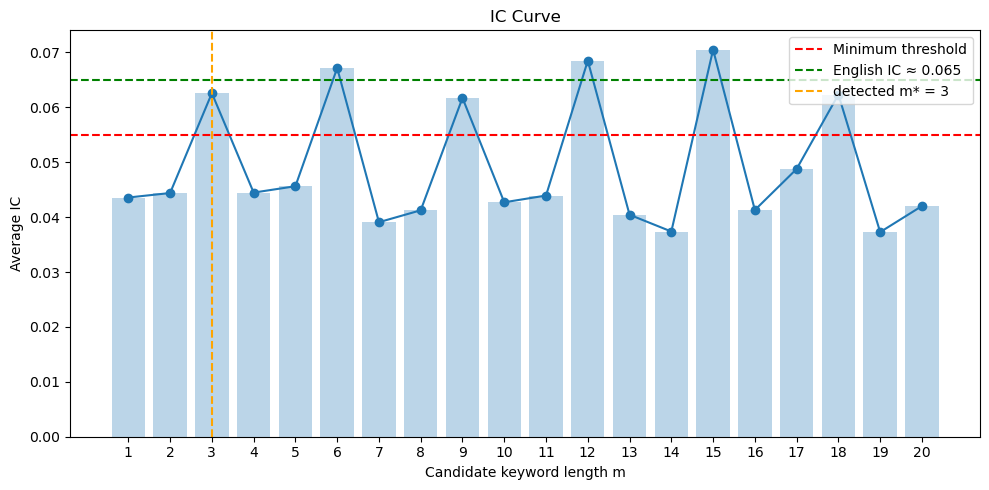

In [923]:
graph_Ics(ICs,max_length,minimum)

The following plot compares the letter frequency distributions of the
ciphertext and the recovered plaintext against the known English reference.
The near-identical blue and orange bars confirm that the attack successfully
recovered the original message, restoring the characteristic frequency
fingerprint of English text.

In [924]:
def LetterFrequencyDistribution(enc,dec):
    enc_chars = (np.frombuffer(enc.upper().encode(), dtype=np.uint8) - ord('A')).astype(int)
    dec_chars = (np.frombuffer(dec.upper().encode(), dtype=np.uint8) - ord('A')).astype(int)
    enc_chars = enc_chars[enc_chars <= 25]
    dec_chars = dec_chars[dec_chars <= 25]
    enc_freq = np.bincount(enc_chars, minlength=26) / len(enc_chars) * 100
    dec_freq = np.bincount(dec_chars, minlength=26) / len(dec_chars) * 100
    x = np.arange(26)
    width = 0.35
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - width/2, enc_freq, width, label="Ciphertext")
    ax.bar(x + width/2, dec_freq, width, label="Recovered plaintext") 
    ax.set_xlabel("Letter")
    ax.set_ylabel("Frequency (%)")
    ax.plot(x, english_freq, marker='o', linestyle='--', color='red', label="English reference")
    ax.set_xticks(x)   
    ax.set_title("Letter Frequency Distribution")
    ax.legend()
    ax.set_xticklabels([chr(i + ord('A')) for i in range(26)])
    plt.tight_layout()
    plt.show()
    

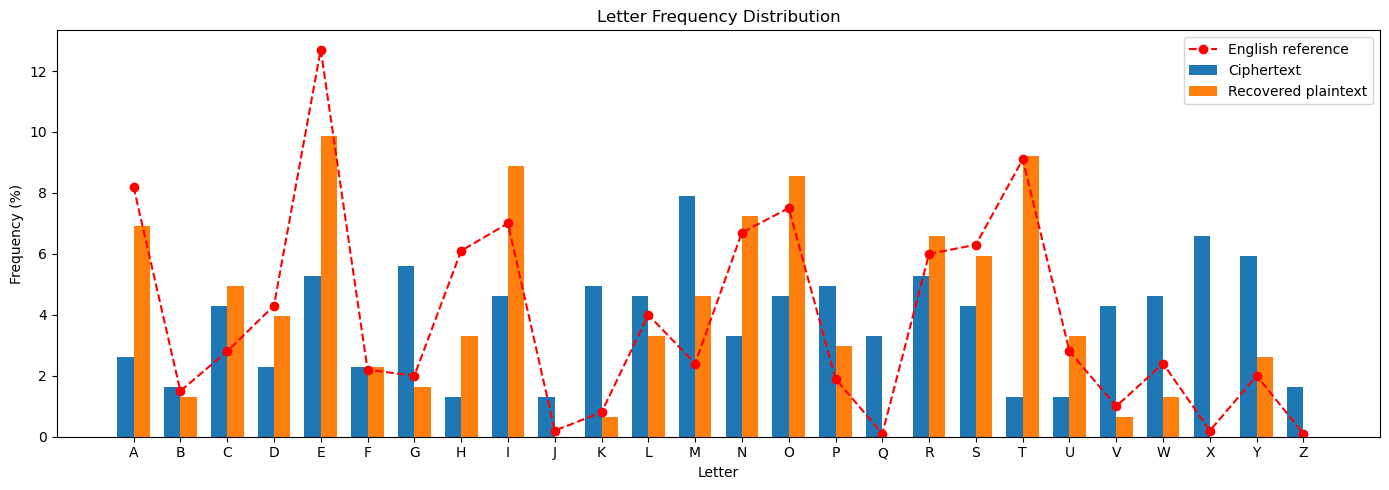

In [925]:
LetterFrequencyDistribution(encrypt_vigenere,dec)

The Caesar and Vigenère ciphers explored in this section extend beyond
their mathematical formulation into a richer historical tradition. For
an interactive and playful take on these ciphers, visit
[Cryptomind](https://cryptomind.techlab.cloud/) — an educational platform
developed alongside this project, where enthusiasts create and solve
historical cryptographic challenges.

## 3. Hill Cipher

The Hill cipher, introduced by Lester S. Hill in 1929, is a polygraphic
substitution cipher based on linear algebra. Unlike the Caesar and Vigenère
ciphers, which operate on individual letters, the Hill cipher encrypts
fixed-size **blocks** of letters simultaneously using matrix multiplication
over $\mathbb{Z}_{26}$. This makes it resistant to simple frequency
analysis — the frequency of individual letters in the ciphertext no longer
directly reflects the plaintext distribution, since each ciphertext letter
depends on multiple plaintext letters at once.

Throughout this section all key matrices are $2 \times 2$, so each block
consists of two letters. The key matrix $K$ must satisfy the invertibility
condition established in Section 1.4:

$$\gcd(\det(K),\ 26) = 1$$

We use the key matrix from Section 1.4:

$$K = \begin{pmatrix} 3 & 3 \\ 2 & 5 \end{pmatrix}, \qquad
\det(K) = 9, \qquad \gcd(9, 26) = 1 \ \checkmark$$

Despite its resistance to frequency analysis, the Hill cipher is
fundamentally broken by the **known-plaintext attack** — an attack that
exploits the linearity of the transformation to recover the key matrix
from a small number of plaintext-ciphertext block pairs. This attack is
demonstrated in Section 3.3.

### 3.1 Encryption

The plaintext is first split into consecutive 2-letter blocks. Each block
is converted into a column vector $\mathbf{p} \in \mathbb{Z}_{26}^2$ by
mapping each letter to its numerical equivalent. The ciphertext vector
is then obtained by:

$$\mathbf{c} \equiv K \cdot \mathbf{p} \pmod{26}$$

If the plaintext has an odd number of letters, a padding letter
$\texttt{X}$ is appended to complete the final block.

**Example**

Encrypting $\texttt{MATH}$ with key matrix $K$. The plaintext splits into
two blocks: $\texttt{MA}$ and $\texttt{TH}$.

$$\texttt{MA} \rightarrow \begin{pmatrix} 12 \\ 0 \end{pmatrix}, \qquad
\texttt{TH} \rightarrow \begin{pmatrix} 19 \\ 7 \end{pmatrix}$$

Applying encryption to each block:

$$K \cdot \begin{pmatrix} 12 \\ 0 \end{pmatrix} =
\begin{pmatrix} 3 & 3 \\ 2 & 5 \end{pmatrix}
\begin{pmatrix} 12 \\ 0 \end{pmatrix} =
\begin{pmatrix} 36 \\ 24 \end{pmatrix} \equiv
\begin{pmatrix} 10 \\ 24 \end{pmatrix} \pmod{26}
\rightarrow \texttt{KY}$$

$$K \cdot \begin{pmatrix} 19 \\ 7 \end{pmatrix} =
\begin{pmatrix} 3 & 3 \\ 2 & 5 \end{pmatrix}
\begin{pmatrix} 19 \\ 7 \end{pmatrix} =
\begin{pmatrix} 78 \\ 73 \end{pmatrix} \equiv
\begin{pmatrix} 0 \\ 21 \end{pmatrix} \pmod{26}
\rightarrow \texttt{AV}$$

$$\texttt{MATH} \xrightarrow{K} \texttt{KYAV}$$

The following cell implements encryption:

In [926]:
def hill_cipher_encryption(plain_text,matrix):
    if sp.gcd( sp.Matrix(matrix).det(),26) != 1: return None
    chars  = (np.frombuffer(plain_text.upper().encode(), dtype=np.uint8) - ord('A')).astype(int)
    padded = np.append(chars, ord('X') - ord('A')) if len(chars) % 2 != 0 else chars
    blocks = padded.reshape(2, -1, order='F')
    encrypted_blocks  = (matrix @ blocks) % 26
    result = encrypted_blocks.reshape(-1, order='F')
    return ''.join((result + ord('A')).astype(np.uint8).tobytes().decode())

In [927]:
plaintext = "MATH"
encrypted = hill_cipher_encryption(plaintext,matrix)
print(encrypted)

KYAV


### 3.2 Decryption

Decryption reverses the matrix multiplication using the modular matrix
inverse $K^{-1} \pmod{26}$, computed in Section 1.4:

$$\mathbf{p} \equiv K^{-1} \cdot \mathbf{c} \pmod{26}$$

The inverse key matrix for our example is:

$$K^{-1} \equiv \begin{pmatrix} 15 & 17 \\ 20 & 9 \end{pmatrix} \pmod{26}$$

**Example**

Decrypting $\texttt{KYAV}$ back to $\texttt{MATH}$:

$$K^{-1} \cdot \begin{pmatrix} 10 \\ 24 \end{pmatrix} =
\begin{pmatrix} 15 & 17 \\ 20 & 9 \end{pmatrix}
\begin{pmatrix} 10 \\ 24 \end{pmatrix} =
\begin{pmatrix} 558 \\ 416 \end{pmatrix} \equiv
\begin{pmatrix} 12 \\ 0 \end{pmatrix} \pmod{26}
\rightarrow \texttt{MA}$$

$$K^{-1} \cdot \begin{pmatrix} 0 \\ 21 \end{pmatrix} =
\begin{pmatrix} 15 & 17 \\ 20 & 9 \end{pmatrix}
\begin{pmatrix} 0 \\ 21 \end{pmatrix} =
\begin{pmatrix} 357 \\ 189 \end{pmatrix} \equiv
\begin{pmatrix} 19 \\ 7 \end{pmatrix} \pmod{26}
\rightarrow \texttt{TH}$$

$$\texttt{KYAV} \xrightarrow{K^{-1}} \texttt{MATH}$$

The following cell implements decryption:

In [928]:
def hill_cipher_decryption(encrypted , matrix , isOdd):
    original_length = len(encrypted)
    inverse = np.array(sp.Matrix(matrix).inv_mod(26)).astype(int)
    chars  = (np.frombuffer(encrypted.upper().encode(), dtype=np.uint8) - ord('A')).astype(int)
    padded = np.append(chars, ord('X') - ord('A')) if len(chars) % 2 != 0 else chars
    blocks = padded.reshape(2, -1, order='F')
    decrypted_blocks  = (inverse @ blocks) % 26
    result = decrypted_blocks.reshape(-1, order='F')
    if isOdd: 
        result = result[:-1]
    return ''.join((result + ord('A')).astype(np.uint8).tobytes().decode())
   
    

In [929]:
decrypted = hill_cipher_decryption(encrypted , matrix, len(plaintext) % 2 == 1)
print(decrypted)
assert decrypted == plaintext

MATH


### 3.3 Known-Plaintext Attack

The Hill cipher is a purely linear transformation, which is its fatal
flaw. If an attacker obtains just two plaintext-ciphertext block pairs,
they can recover the key matrix $K$ directly — without any knowledge
of $K$ itself.

Given two plaintext column vectors $\mathbf{p}_1, \mathbf{p}_2$ and their
corresponding ciphertext vectors $\mathbf{c}_1, \mathbf{c}_2$, the
encryption relationship is:

$$K \cdot P \equiv C \pmod{26}$$

where $P$ and $C$ are the $2 \times 2$ matrices formed by stacking the
plaintext and ciphertext vectors as columns:

$$P = \begin{pmatrix} \mathbf{p}_1 & \mathbf{p}_2 \end{pmatrix}, \qquad
C = \begin{pmatrix} \mathbf{c}_1 & \mathbf{c}_2 \end{pmatrix}$$

If $P$ is invertible mod 26 — that is, $\gcd(\det(P), 26) = 1$ — the
attacker recovers the key directly:

$$K \equiv C \cdot P^{-1} \pmod{26}$$

For a $2 \times 2$ key this requires just **two known block pairs** —
a trivially small amount of information. This completely breaks the
cipher regardless of the key matrix chosen.

Additionally, the Hill cipher provides **no diffusion beyond the block
boundary** — each ciphertext block depends only on its corresponding
plaintext block, so structural patterns at the block level are preserved
in the ciphertext. Modern ciphers such as AES address both weaknesses
through non-linear substitution layers and cross-block mixing, making
equivalent attacks computationally infeasible.

To demonstrate, we take the first two plaintext-ciphertext block pairs
from the $\texttt{MATH}$ example — $\texttt{MA} \to \texttt{KY}$ and
$\texttt{TH} \to \texttt{AV}$ — and recover $K$ using the formula above.
The following cell implements the attack and verifies the result against
the original key matrix using SymPy:

In [930]:
def known_plaintext_attack(known_text, cipher_text): 
    known_text_chars  = (np.frombuffer(known_text.upper().encode(), dtype=np.uint8) - ord('A')).astype(int) 
    cipher_text_chars  = (np.frombuffer(cipher_text.upper().encode(), dtype=np.uint8) - ord('A')).astype(int)
    P = known_text_chars.reshape(2, 2, order='F')
    C = cipher_text_chars[:4].reshape(2, 2, order='F')
    P_mod_inversed = np.array(sp.Matrix(P).inv_mod(26)).astype(int)
    K = (C @ P_mod_inversed) % 26
    return hill_cipher_decryption(cipher_text,K , False)
    
    

In [931]:
plain_text = "HILLCIPHER"
know_plain_text = "HILL"
cipher_text = hill_cipher_encryption(plain_text,matrix)
dec_text = known_plaintext_attack(know_plain_text,cipher_text)
print(dec_text)
assert dec_text == plain_text

HILLCIPHER


## 4. Modern Cryptography

The classical ciphers of Section 2 and the Hill cipher of Section 3,
despite their mathematical elegance, share a fundamental weakness —
they are all **symmetric**: the same key is used for both encryption
and decryption. This means any two parties wishing to communicate
securely must first exchange a secret key through a secure channel,
creating a circular dependency.

Modern cryptography breaks this dependency through two key innovations:

- **Asymmetric encryption** — two mathematically linked keys, one
  public and one private, such that encrypting with one can only be
  reversed with the other. Security rests not on secrecy of the
  algorithm but on the computational hardness of certain mathematical
  problems.
- **Cryptographic hash functions** — one-way functions that map
  arbitrary input to a fixed-size digest, used for integrity
  verification, digital signatures, and password storage.

This section implements RSA encryption and digital signatures from
scratch using the mathematical tools established in Section 1, then
demonstrates AES symmetric encryption, cryptographically secure
randomness, and closes with the quantum computing threat to current
cryptographic standards.

### 4.1 RSA

RSA, introduced by Rivest, Shamir and Adleman in 1977, is the most
widely deployed asymmetric encryption scheme. Its security rests on
the **integer factorization problem** — given a large composite number
$n = pq$, it is computationally infeasible to recover the prime factors
$p$ and $q$ when they are sufficiently large.

The public key $(e, n)$ is shared openly. The private key $(d, n)$
is kept secret. Anyone can encrypt a message using the public key,
but only the holder of the private key can decrypt it.

#### 4.1.1 Euler's Theorem

The correctness of RSA rests on Euler's theorem — a result from number
theory that generalises Fermat's little theorem to composite moduli.

**Euler's Totient Function**

Euler's totient function $\phi(n)$ counts the number of integers in
$\{1, 2, \dots, n\}$ that are coprime to $n$:

$$\phi(n) = \left|\{a \in \mathbb{Z} : 1 \leq a \leq n,\ \gcd(a, n) = 1\}\right|$$

For a prime $p$, every integer from $1$ to $p - 1$ is coprime to $p$,
so $\phi(p) = p - 1$. For the product of two distinct primes
$n = pq$, the totient satisfies:

$$\phi(pq) = (p - 1)(q - 1)$$

This identity is what makes RSA key generation possible — it allows
computation of $\phi(n)$ without factoring $n$, but only for someone
who knows $p$ and $q$.

For example, with $p = 5$ and $q = 7$:

$$n = 35, \qquad \phi(35) = 4 \times 6 = 24$$

**The Theorem**

Euler's theorem states that for any integer $a$ coprime to $n$:

$$\gcd(a, n) = 1 \implies a^{\phi(n)} \equiv 1 \pmod{n}$$

Fermat's little theorem, used in Section 4.1.2 as the basis for the
Miller-Rabin test, is the special case where $n$ is prime and
$\phi(n) = n - 1$:

$$a^{p-1} \equiv 1 \pmod{p}$$

**Proof of RSA Correctness**

We can now prove that RSA decryption recovers the original message.
The private exponent $d$ is chosen such that:

$$ed \equiv 1 \pmod{\phi(n)}$$

which means there exists an integer $k$ such that $ed = 1 + k\,\phi(n)$.
For any message $m$ with $\gcd(m, n) = 1$:

$$m^{ed} = m^{1 + k\,\phi(n)} = m \cdot \left(m^{\phi(n)}\right)^k
\equiv m \cdot 1^k \equiv m \pmod{n}$$

The second step follows directly from Euler's theorem. This guarantees
that encrypting with $e$ and decrypting with $d$ — or vice versa — is
the identity operation. The result extends to all $m \in \mathbb{Z}_n$
(including $\gcd(m, n) \neq 1$) via the Chinese Remainder Theorem.

The following cell verifies both the totient identity and Euler's
theorem numerically using SymPy:

In [954]:
def eulers_totient(p,q): 
    return (p - 1) * (q - 1)

In [955]:
p, q = 61, 53
n = p * q
phi_n = eulers_totient(p, q)

assert sp.totient(p * q) == phi_n

Euler's theorem states that $a^{\phi(n)} \equiv 1 \pmod{n}$ for any
$a$ coprime to $n$. The following cell verifies this numerically:

In [956]:
a = 10
assert sp.gcd(a, n) == 1
assert pow(a, phi_n, n) == 1

Finally, we verify the RSA round-trip: encrypting with the public
exponent $e$ and decrypting with the private exponent
$d \equiv e^{-1} \pmod{\phi(n)}$ recovers the original message:

In [959]:
e = 17

d = sp.mod_inverse(e, phi_n)
m = 42
cipher = pow(m, e, n)
plain = pow(cipher, d, n)
assert plain == m

#### 4.1.2 Miller-Rabin Primality Test

Generating RSA keys requires large prime numbers. Rather than relying
on a library, we implement the **Miller-Rabin primality test** — the
algorithm used in practice by real cryptographic systems.

It is based on Fermat's little theorem: if $n$ is prime then for any
$a$ not divisible by $n$:

$$a^{n-1} \equiv 1 \pmod{n}$$

Miller-Rabin strengthens this by factoring out all powers of 2 from
$n - 1$. Since $n$ is an odd prime candidate, $n - 1$ is always even
and can be written uniquely as:

$$n - 1 = 2^r \cdot d$$

where:
- $r$ is the **number of times 2 divides** $n-1$ exactly — how many
  times you can halve $n-1$ before the result becomes odd
- $d$ is the **odd part** of $n-1$ — what remains after all factors
  of 2 have been divided out

Both are computed by repeatedly dividing $n-1$ by 2 until the result
is odd, counting the divisions in $r$ and keeping the final result as
$d$:

$$n - 1 \xrightarrow{\div 2} \xrightarrow{\div 2} \cdots
\xrightarrow{\div 2} d \quad (r \text{ divisions, no remainder})$$

For example:

$$n = 13 \Rightarrow n-1 = 12 \xrightarrow{\div 2} 6
\xrightarrow{\div 2} 3 \Rightarrow r = 2,\ d = 3$$

$$n = 17 \Rightarrow n-1 = 16 \xrightarrow{\div 2} 8
\xrightarrow{\div 2} 4 \xrightarrow{\div 2} 2
\xrightarrow{\div 2} 1 \Rightarrow r = 4,\ d = 1$$

For a randomly chosen witness $a$, the test checks whether the sequence:

$$a^d,\ a^{2d},\ a^{4d},\ \dots,\ a^{2^r d} \pmod{n}$$

behaves as it must for a true prime — specifically that either
$a^d \equiv 1 \pmod{n}$ or some term in the sequence satisfies
$a^{2^j d} \equiv n-1 \pmod{n}$ for some $j < r$. If any witness
$a$ fails this condition, $n$ is **definitely composite**. If $k$
independent witnesses all pass, $n$ is prime with probability at
least $1 - 4^{-k}$. With $k = 20$ witnesses the error probability
is less than $10^{-12}$.

The following cell implements Miller-Rabin:

In [937]:
def miller_rabin(n , k= 20):
    if n < 2: return False
    if n == 2 or n == 3: return True
    if n % 2 == 0: return False

    r = 0
    d = n - 1
    
    while d % 2 == 0 :
        r += 1
        d //= 2 
    for _ in range(k) :
        a = random.randrange(2, n - 1)
        sequence = [pow(a, (2**j) * d, n) for j in range(r)]
        if pow(a, d, n) == 1 or any(x == n - 1 for x in sequence):
            continue
        else:
            return False
    
    return True

In [938]:
print(miller_rabin(13))  
print(miller_rabin(17))   
print(miller_rabin(15))   
print(miller_rabin(561))

True
True
False
False


The following cell verifies our implementation against SymPy's built-in
`isprime` function, which also uses Miller-Rabin internally. We test
against both prime and composite numbers, including $561$ — the smallest
**Carmichael number**, a composite that fools simpler primality tests
based on Fermat's little theorem alone but is correctly identified as
composite by Miller-Rabin:

$$561 = 3 \times 11 \times 17 \quad \text{(composite, not prime)}$$

In [939]:
assert miller_rabin(13) == sp.isprime(13)
assert miller_rabin(17) == sp.isprime(17)
assert miller_rabin(15) == sp.isprime(15)
assert miller_rabin(561) == sp.isprime(561)

#### 4.1.3 Prime Generation

With Miller-Rabin implemented, we can generate large primes by repeatedly
sampling random odd integers of a given bit length and testing each with
Miller-Rabin until a prime is found:

$$p \leftarrow \text{random odd integer of } b \text{ bits} \quad
\xrightarrow{\text{Miller-Rabin}} \quad \text{prime or try again}$$

A $b$-bit integer $n$ satisfies $2^{b-1} \leq n < 2^b$, so we sample
uniformly from this range and force the result to be odd by setting
the least significant bit to 1. By the **prime number theorem**, the
density of primes near $2^b$ is approximately $\frac{1}{\ln(2^b)} =
\frac{1}{b \ln 2}$, so on average the loop runs $b \ln 2$ iterations
before finding a prime — for 512-bit primes this is roughly 355
iterations, each taking milliseconds.

The following cell implements prime generation and verifies the result
against SymPy:

In [965]:
def generate_prime(bits):
    while True :
        number = random.getrandbits(bits)
        number |= (1 << (bits - 1))
        number |= 1
        if miller_rabin(number) : 
            return number
    
    


In [966]:
p = generate_prime(512)
assert sp.isprime(p)
print(p)

12485621457015995361211817866759443669016014601369982282262724269094369687288678685785706430898329630409206288706389760254248480224272298435487056244844259
